In [1]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt

In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

In [3]:
model=LogisticRegression(random_state=42,max_iter=100)
model.fit(X_train,y_train)

LogisticRegression(random_state=42)

In [6]:
y_pred=model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [7]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[915 118]
 [181 193]]


In [8]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [9]:
y_prob = model.predict_proba(X_test)[:, 1]

In [10]:
auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {auc:.4f}")

ROC-AUC Score: 0.8319


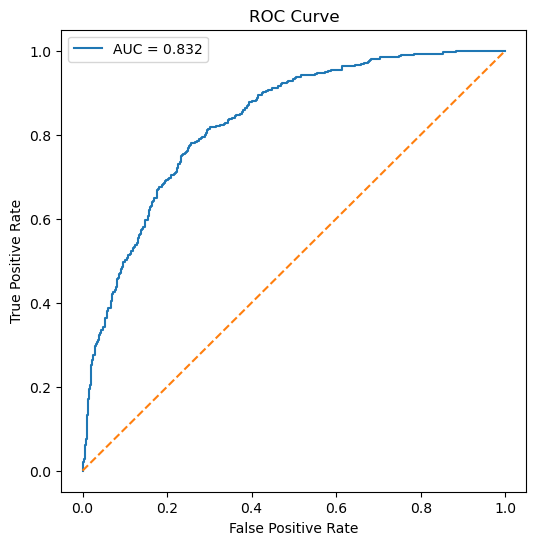

In [11]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")   # Random guessing
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Conclusion

In this notebook, we built our first baseline classification model using **Logistic Regression** to predict customer churn.

Before training the model, we explored the intuition behind Logistic Regression, including the sigmoid function, probability predictions, and decision thresholds. We then trained the model on the preprocessed data and evaluated its performance using multiple classification metrics.

### Model Performance

- **Accuracy:** 79%
- **Precision (Churn):** 62%
- **Recall (Churn):** 52%
- **F1-Score (Churn):** 56%
- **ROC-AUC Score:** 0.8319

### Key Insights

- The model achieved a good overall accuracy of **79%**.
- It performed well in identifying customers who stay with the company but detected only about **52%** of customers who actually churned.
- The **ROC-AUC score of 0.8319** indicates that the model has a strong ability to distinguish between customers who churn and those who stay.
- Since the dataset is moderately imbalanced, relying solely on accuracy would have been misleading. Metrics such as **Precision, Recall, F1-Score, and ROC-AUC** provided a much better understanding of the model's performance.

### Next Steps

While Logistic Regression provides a strong baseline, more advanced models such as **Decision Tree** and **Random Forest** may capture complex relationships in the data and improve churn prediction. In the next notebook, we will compare multiple classification models and identify the best-performing algorithm for this problem.